Практика 4.1
Студент Карелин Д.В.
Вариант 6

**Задание 1**

Сравнение ElasticNet

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd

# Данные
data = load_diabetes()
X, y = data.data, data.target

# Модели
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, max_iter=10000))
])

elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1],
        alphas=np.logspace(-4, 2, 30),
        cv=5,
        max_iter=10000
    ))
])

models = {
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic
}

results = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    coefs = model.named_steps['model'].coef_
    non_zero = np.sum(coefs != 0)

    results.append([name, rmse, non_zero])

df = pd.DataFrame(results, columns=["Model", "RMSE", "Non-zero coefs"])
print(df)

# Параметры ElasticNet
elastic_model = elastic.named_steps['model']
print("\nElasticNet best alpha:", elastic_model.alpha_)
print("ElasticNet best l1_ratio:", elastic_model.l1_ratio_)

        Model       RMSE  Non-zero coefs
0       Ridge  53.485346              10
1       Lasso  53.496765               9
2  ElasticNet  53.494263               9

ElasticNet best alpha: 0.07880462815669913
ElasticNet best l1_ratio: 1.0


ElasticNet сохраняет разреженность модели как Lasso, но при этом лучше работает с коррелированными признаками как Ridge

Задание 2 - Влияние объема данных

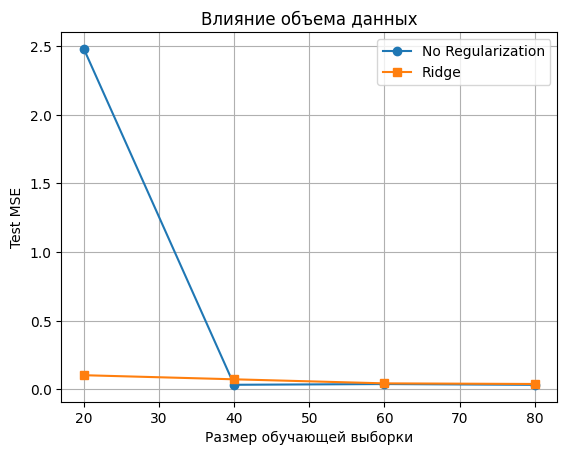

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# синтетика (если уже есть — используй свою)
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 100)

sizes = [20, 40, 60, 80]
ridge_errors = []
linear_errors = []

for size in sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=size, random_state=42)

    # Linear (без регуляризации)
    model_lin = Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0))  # почти OLS
    ])

    # Ridge
    model_ridge = Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ])

    model_lin.fit(X_train, y_train)
    model_ridge.fit(X_train, y_train)

    y_pred_lin = model_lin.predict(X_test)
    y_pred_ridge = model_ridge.predict(X_test)

    linear_errors.append(mean_squared_error(y_test, y_pred_lin))
    ridge_errors.append(mean_squared_error(y_test, y_pred_ridge))

# график
plt.plot(sizes, linear_errors, marker='o', label='No Regularization')
plt.plot(sizes, ridge_errors, marker='s', label='Ridge')
plt.xlabel("Размер обучающей выборки")
plt.ylabel("Test MSE")
plt.title("Влияние объема данных")
plt.legend()
plt.grid()
plt.show()

При малом количестве данных регуляризация существенно улучшает качество модели, снижая переобучение

При увеличении объема данных разница между моделями уменьшается

Задание 3 - Анализ остатков

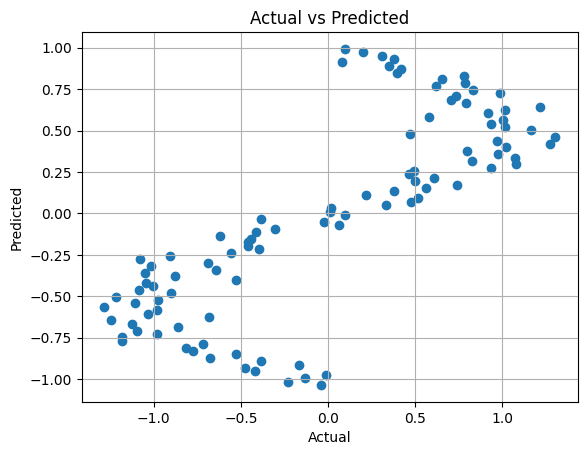

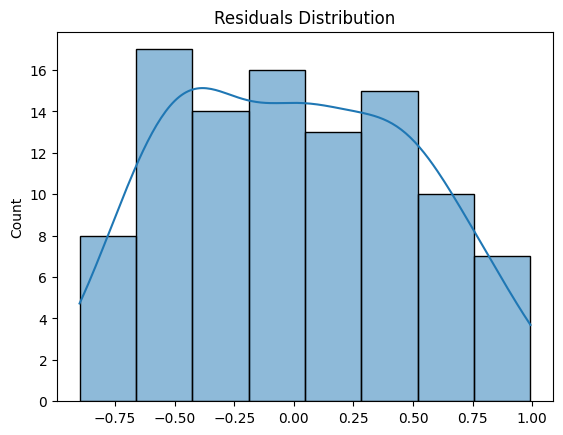

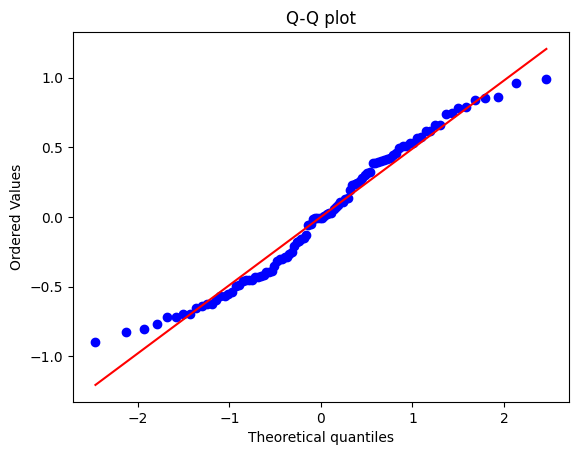

Shapiro p-value: 0.017300311533314704


In [ ]:
import seaborn as sns
from scipy import stats

# берём лучшую модель (например Ridge или ElasticNet)
best_model = ridge
best_model.fit(X, y)

y_pred = best_model.predict(X)
residuals = y - y_pred

# 1. Actual vs Predicted
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid()
plt.show()

# 2. Гистограмма остатков
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot")
plt.show()

# 4. Shapiro test
stat, p = stats.shapiro(residuals)
print("Shapiro p-value:", p)

Если распределение остатков отклоняется от нормального, это может означать:

 - наличие нелинейности в данных
 - гетероскедастичность (непостоянная дисперсия ошибок)
 - недостаточную сложность модели